# PLC exploratory betting and economic backtest

This notebook is the inspectable reporting companion for the sealed Development-only analysis.
It reads the row-level OOF and summary artifacts produced by
`kra_analytics.exploratory_betting_backtest`; it does not retrain a model or access Validation.

Final PLC odds and confirmed payouts are post-cutoff information. All ROI and EV results below
are retrospective diagnostics, not deployable strategy performance.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
OUTPUT = ROOT / 'data/exports/modeling/plc_exploratory_betting_backtest_v1'
result = json.loads((OUTPUT / 'result.json').read_text(encoding='utf-8'))
thresholds = pd.read_csv(OUTPUT / 'confidence_threshold_summary.csv')
buckets = pd.read_csv(OUTPUT / 'probability_bucket_summary.csv')
monthly = pd.read_csv(OUTPUT / 'monthly_strategy_summary.csv')
edges = pd.read_csv(OUTPUT / 'retrospective_ev_summary.csv')
cumulative = pd.read_csv(OUTPUT / 'cumulative_profit.csv')
assert result['validation_access_count'] == 0
assert result['rows_on_or_after_2024_07_01_loaded'] == 0
assert result['oof_restoration']['max_absolute_delta'] <= 1e-12

## Coverage and fixed Top1 settlement

In [2]:
pd.DataFrame([
    result['settlement_audit'],
    result['top1_fixed'],
], index=['settlement_audit', 'top1_fixed']).T

,settlement_audit,top1_fixed
prediction_rows,19168.0,NaN
prediction_races,1821.0,NaN
runner_odds_joined_rows,19168.0,NaN
runner_odds_join_rate,1.0,NaN
official_positive_rows,5462.0,NaN
official_payout_rows_matched,5462.0,NaN
target_payout_mismatch_rows,0.0,NaN
excluded_rows,0.0,NaN
excluded_races,0.0,NaN
eligible_rows,19168.0,NaN


## Predeclared confidence sensitivity (no threshold selection)

,threshold,bets,bet_rate,hit_rate,roi,net_profit,max_drawdown,longest_losing_streak
0,0.35,1780,0.977485,0.620225,-0.126629,-225.4,228.5,6
1,0.40,1720,0.944536,0.626163,-0.124535,-214.2,218.8,8
2,0.45,1553,0.852828,0.642627,-0.107856,-167.5,173.0,9
3,0.50,1265,0.694673,0.652174,-0.121660,-153.9,160.1,9
4,0.55,880,0.483251,0.689773,-0.104318,-91.8,94.8,6
5,0.60,530,0.291049,0.732075,-0.088491,-46.9,47.2,3
6,0.65,287,0.157606,0.735192,-0.124390,-35.7,38.6,3
7,0.70,102,0.056013,0.774510,-0.080392,-8.2,11.5,2


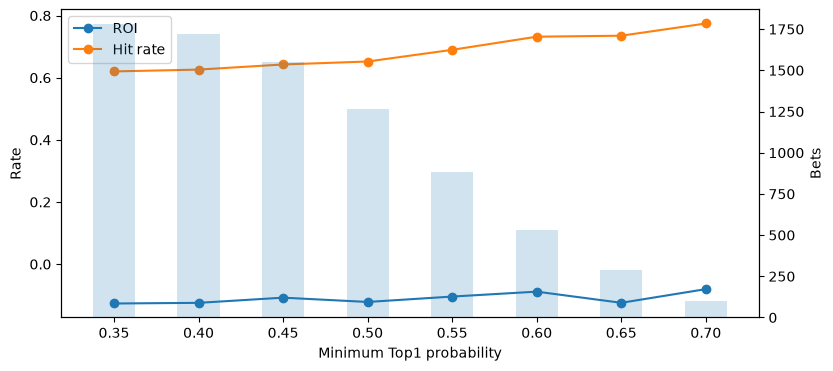

In [3]:
display(thresholds[['threshold', 'bets', 'bet_rate', 'hit_rate', 'roi',
                    'net_profit', 'max_drawdown', 'longest_losing_streak']])
fig, left = plt.subplots(figsize=(9, 4))
left.plot(thresholds['threshold'], thresholds['roi'], marker='o', label='ROI')
left.plot(thresholds['threshold'], thresholds['hit_rate'], marker='o', label='Hit rate')
left.set(xlabel='Minimum Top1 probability', ylabel='Rate')
right = left.twinx()
right.bar(thresholds['threshold'], thresholds['bets'], width=0.025, alpha=0.2)
right.set_ylabel('Bets')
left.legend(); plt.show()

## Probability calibration and final-market payout structure

,probability_bucket,runner_count,race_count,mean_predicted_probability,observed_plc_rate,calibration_gap,mean_final_place_odds,median_final_place_odds,hit_runner_mean_confirmed_payout
0,"(-0.001, 0.1]",1680,1037,0.074093,0.055357,-0.018736,13.930179,11.6,7.691398
1,"(0.1, 0.2]",5152,1748,0.151681,0.135675,-0.016005,8.044080,6.2,5.255365
2,"(0.2, 0.3]",4862,1737,0.247731,0.243521,-0.004210,4.616763,3.4,3.200338
3,"(0.3, 0.4]",3412,1601,0.345497,0.359906,0.014409,2.866295,2.3,2.340879
4,"(0.4, 0.5]",2173,1341,0.446581,0.495168,0.048587,1.966176,1.7,1.720167
5,"(0.5, 0.6]",1298,980,0.543349,0.580894,0.037545,1.552003,1.5,1.462334
6,"(0.6, 0.7]",489,450,0.643106,0.713701,0.070596,1.325358,1.2,1.272493
7,"(0.7, 0.8]",96,96,0.731111,0.760417,0.029306,1.206250,1.1,1.171233
8,"(0.8, 0.9]",6,6,0.824391,1.000000,0.175609,1.383333,1.1,1.383333
9,"(0.9, 1.0]",0,0,NaN,NaN,NaN,NaN,NaN,NaN


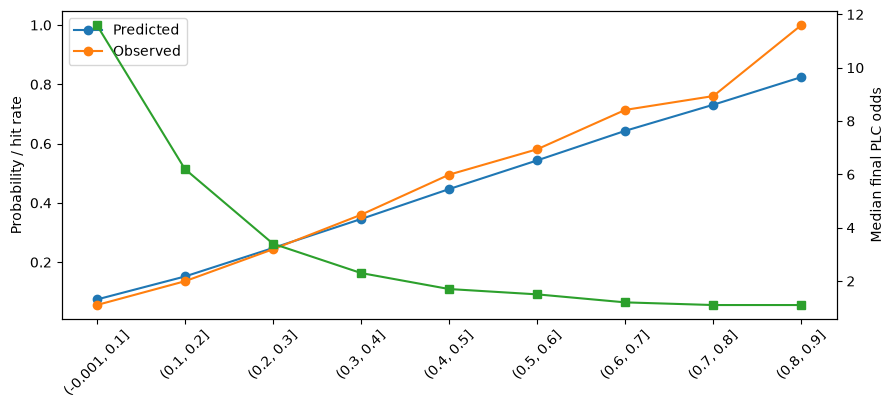

In [4]:
display(buckets)
fig, left = plt.subplots(figsize=(10, 4))
x = range(len(buckets))
left.plot(x, buckets['mean_predicted_probability'], marker='o', label='Predicted')
left.plot(x, buckets['observed_plc_rate'], marker='o', label='Observed')
left.set_xticks(list(x), buckets['probability_bucket'], rotation=45)
left.set_ylabel('Probability / hit rate')
right = left.twinx()
right.plot(x, buckets['median_final_place_odds'], color='tab:green', marker='s')
right.set_ylabel('Median final PLC odds')
left.legend(); plt.show()

## Hindsight EV buckets — not decision-time EV

In [5]:
display(edges)

,edge_bucket,runner_count,race_count,observed_hit_rate,mean_final_place_odds,mean_hindsight_ev,retrospective_realized_roi
0,<=-0.50,2102,1260,0.375357,2.654377,-0.598392,-0.300714
1,"(-0.50,0.00]",10400,1819,0.361250,3.287096,-0.266017,-0.227308
2,"(0.00,0.25]",2436,1383,0.201560,5.744869,0.114086,-0.210632
3,"(0.25,0.50]",1322,985,0.133132,7.572693,0.361550,-0.319062
4,"(0.50,1.00]",1427,982,0.110722,10.177295,0.713952,-0.232726
5,>1.00,1481,852,0.061445,17.446050,2.107996,-0.243687


## Monthly stability and cumulative risk

,month,bets,hit_rate,roi,net_profit
0,2023-07,152,0.578947,-0.158553,-24.1
1,2023-08,132,0.613636,-0.090152,-11.9
2,2023-09,143,0.622378,-0.085315,-12.2
3,2023-10,157,0.560510,-0.260510,-40.9
4,2023-11,147,0.653061,-0.131293,-19.3
5,2023-12,190,0.657895,-0.081579,-15.5
6,2024-01,144,0.618056,-0.077083,-11.1
7,2024-02,108,0.611111,-0.104630,-11.3
8,2024-03,180,0.611111,-0.153333,-27.6
9,2024-04,144,0.597222,-0.154861,-22.3


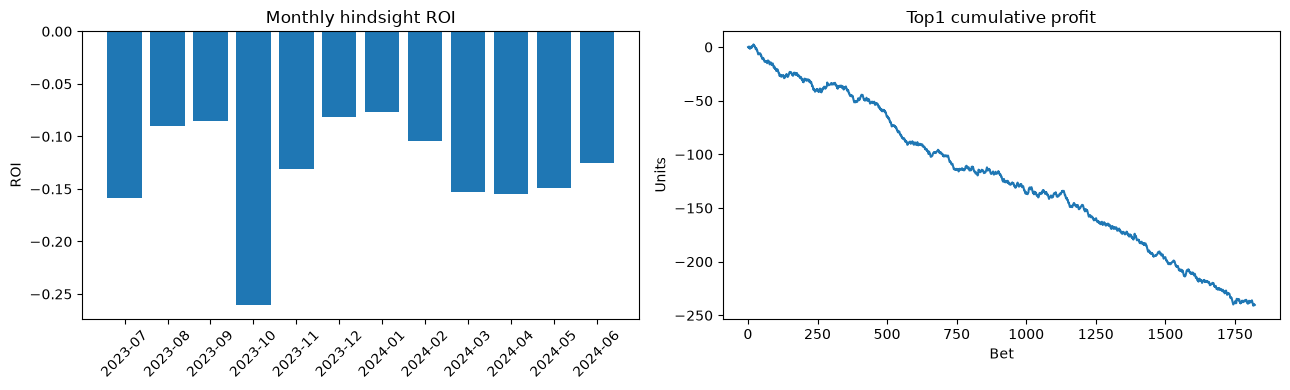

In [6]:
display(monthly[['month', 'bets', 'hit_rate', 'roi', 'net_profit']])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(monthly['month'], monthly['roi'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set(title='Monthly hindsight ROI', ylabel='ROI')
axes[1].plot(cumulative['bet_number'], cumulative['cumulative_profit'])
axes[1].set(title='Top1 cumulative profit', xlabel='Bet', ylabel='Units')
plt.tight_layout(); plt.show()

## Interpretation boundary

- The model strongly overlaps the final market favorite structure, but no decision-time odds were
  observed.
- Fixed Top1 and every predeclared confidence threshold lost money in this Development OOF period.
- Final-payout EV buckets are hindsight-only and cannot be used to select a live edge rule.
- No Validation or data on/after 2024-07-01 was accessed.